## Imports

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import random

## Part 1

In [4]:
def exponential_rng(n, lam=1):
    U = np.random.uniform(0, 1, n)
    return -np.log(U) / lam

In [5]:
n = 10000
lam = 1

exp_data = exponential_rng(n, lam)

### Plotting histogram

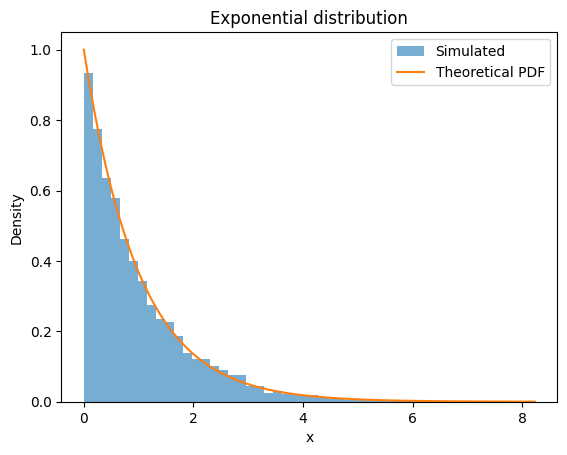

In [6]:
x = np.linspace(0, max(exp_data), 500)
theoretical_pdf = lam * np.exp(-lam * x)

plt.hist(exp_data, bins=50, density=True, alpha=0.6, label="Simulated")
plt.plot(x, theoretical_pdf, label="Theoretical PDF")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Exponential distribution")
plt.legend()
plt.show()

In [8]:
ks_result = stats.kstest(exp_data, "expon", args=(0, 1/lam))

print("KS statistic:", ks_result.statistic)
print("p-value:", ks_result.pvalue)

KS statistic: 0.010871582719950923
p-value: 0.18660699119203616


### Box-muller

In [9]:
def normal_box_muller(n, mu=0, sigma=1):
    U1 = np.random.uniform(0, 1, n)
    U2 = np.random.uniform(0, 1, n)

    Z1 = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)

    return mu + sigma * Z1

In [10]:
mu = 0
sigma = 1

normal_data = normal_box_muller(n, mu, sigma)

### Plotting histogram

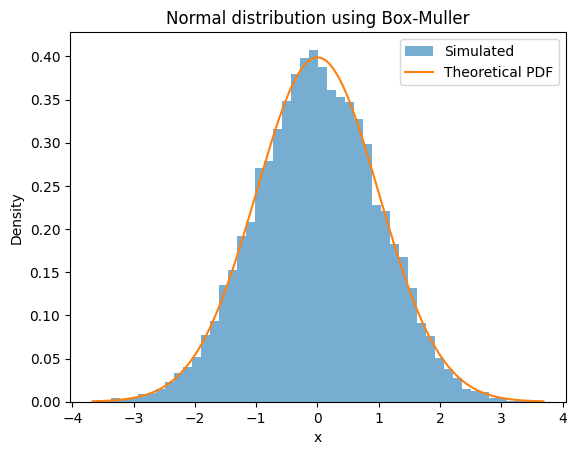

In [11]:
x = np.linspace(min(normal_data), max(normal_data), 500)
theoretical_pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.hist(normal_data, bins=50, density=True, alpha=0.6, label="Simulated")
plt.plot(x, theoretical_pdf, label="Theoretical PDF")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Normal distribution using Box-Muller")
plt.legend()
plt.show()

In [12]:
ks_result = stats.kstest(normal_data, "norm", args=(mu, sigma))

print("KS statistic:", ks_result.statistic)
print("p-value:", ks_result.pvalue)

KS statistic: 0.005907832339253294
p-value: 0.8741329723252695


### Pareto

In [13]:
def pareto_rng(n, k, beta=1):
    U = np.random.uniform(0, 1, n)
    return beta * U ** (-1 / k)

### Simulations and histogram

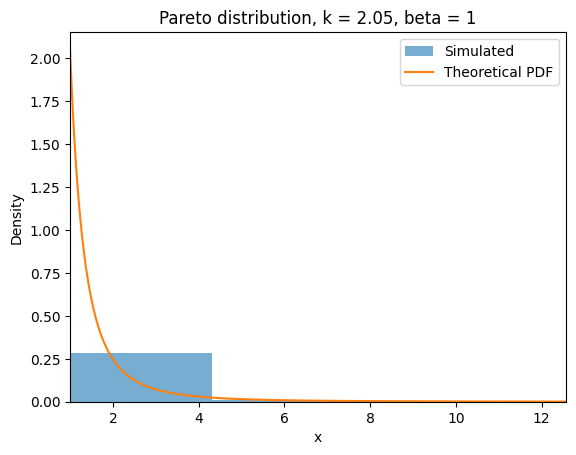

k = 2.05
KS statistic: 0.01035233619518644
p-value: 0.23252568482162683



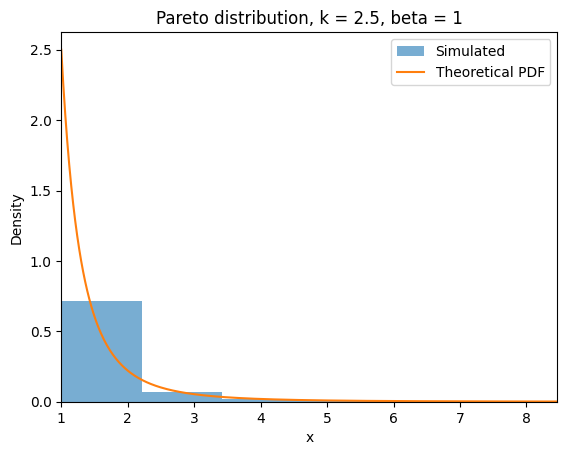

k = 2.5
KS statistic: 0.009412376418338975
p-value: 0.3362796841428166



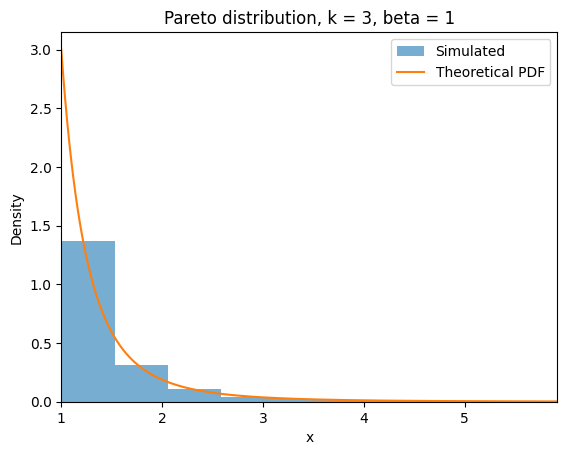

k = 3
KS statistic: 0.006550991750172486
p-value: 0.7814737675380544



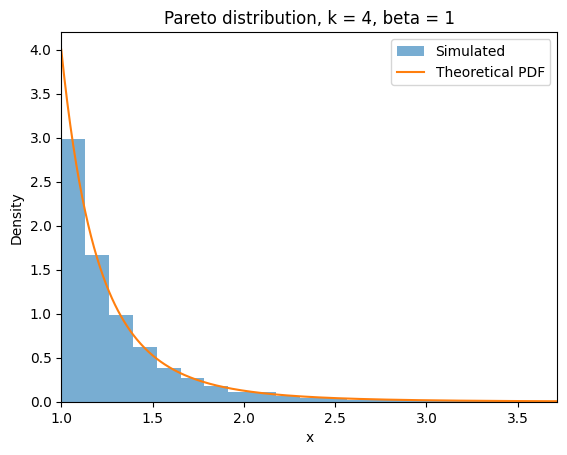

k = 4
KS statistic: 0.008391743586515288
p-value: 0.4793461524838417



In [14]:
beta = 1
k_values = [2.05, 2.5, 3, 4]

pareto_samples = {}

for k in k_values:
    data = pareto_rng(n, k, beta)
    pareto_samples[k] = data

    x = np.linspace(beta, np.percentile(data, 99.5), 500)
    theoretical_pdf = k * beta**k / x**(k + 1)

    plt.hist(data, bins=50, density=True, alpha=0.6, label="Simulated")
    plt.plot(x, theoretical_pdf, label="Theoretical PDF")
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title(f"Pareto distribution, k = {k}, beta = {beta}")
    plt.xlim(beta, np.percentile(data, 99.5))
    plt.legend()
    plt.show()

    ks_result = stats.kstest(data, "pareto", args=(k, 0, beta))

    print("k =", k)
    print("KS statistic:", ks_result.statistic)
    print("p-value:", ks_result.pvalue)
    print()

## Part 2

In [15]:
def pareto_theoretical_mean(k, beta=1):
    return beta * k / (k - 1)


def pareto_theoretical_variance(k, beta=1):
    return beta**2 * k / ((k - 1)**2 * (k - 2))

### Comparison of theoretical values of simulated values

In [16]:
n = 10000
beta = 1
k_values = [2.05, 2.5, 3, 4]

for k in k_values:
    data = pareto_rng(n, k, beta)

    sample_mean = np.mean(data)
    sample_variance = np.var(data, ddof=1)

    theoretical_mean = pareto_theoretical_mean(k, beta)
    theoretical_variance = pareto_theoretical_variance(k, beta)

    print("k =", k)
    print("Sample mean:", sample_mean)
    print("Theoretical mean:", theoretical_mean)
    print("Difference in mean:", sample_mean - theoretical_mean)
    print()
    print("Sample variance:", sample_variance)
    print("Theoretical variance:", theoretical_variance)
    print("Difference in variance:", sample_variance - theoretical_variance)
    print("-" * 40)

k = 2.05
Sample mean: 1.9777978525775908
Theoretical mean: 1.9523809523809526
Difference in mean: 0.025416900196638226

Sample variance: 7.167418876554845
Theoretical variance: 37.18820861678019
Difference in variance: -30.020789740225343
----------------------------------------
k = 2.5
Sample mean: 1.655061924203335
Theoretical mean: 1.6666666666666667
Difference in mean: -0.011604742463331652

Sample variance: 1.5645857032910502
Theoretical variance: 2.2222222222222223
Difference in variance: -0.6576365189311721
----------------------------------------
k = 3
Sample mean: 1.4989899851551818
Theoretical mean: 1.5
Difference in mean: -0.001010014844818219

Sample variance: 0.6136356230322347
Theoretical variance: 0.75
Difference in variance: -0.13636437696776527
----------------------------------------
k = 4
Sample mean: 1.3265086705099676
Theoretical mean: 1.3333333333333333
Difference in mean: -0.00682466282336569

Sample variance: 0.19584387019453026
Theoretical variance: 0.222222222

Based on the theoretical value we expect k = 2.05 to be the worst, which it is.

## Part 3

### Setting parameters

In [19]:
def normal_confidence_intervals(repetitions=100, n=10, mu=0, sigma=1, alpha=0.05):
    mean_covered = 0
    variance_covered = 0

    mean_intervals = []
    variance_intervals = []

    for i in range(repetitions):
        sample = normal_box_muller(n, mu, sigma)

        sample_mean = np.mean(sample)
        sample_var = np.var(sample, ddof=1)
        sample_std = np.sqrt(sample_var)

        # Confidence interval for mean
        t_value = stats.t.ppf(1 - alpha/2, df=n-1)
        mean_lower = sample_mean - t_value * sample_std / np.sqrt(n)
        mean_upper = sample_mean + t_value * sample_std / np.sqrt(n)

        # Confidence interval for variance
        chi2_lower = stats.chi2.ppf(alpha/2, df=n-1)
        chi2_upper = stats.chi2.ppf(1 - alpha/2, df=n-1)

        var_lower = (n - 1) * sample_var / chi2_upper
        var_upper = (n - 1) * sample_var / chi2_lower

        mean_intervals.append((mean_lower, mean_upper))
        variance_intervals.append((var_lower, var_upper))

        if mean_lower <= mu <= mean_upper:
            mean_covered += 1

        if var_lower <= sigma**2 <= var_upper:
            variance_covered += 1

    print("Mean intervals covered true mean:", mean_covered, "out of", repetitions)
    print("Mean coverage:", mean_covered / repetitions)

    print("Variance intervals covered true variance:", variance_covered, "out of", repetitions)
    print("Variance coverage:", variance_covered / repetitions)

    return mean_intervals, variance_intervals

In [20]:
mean_intervals, variance_intervals = normal_confidence_intervals()

Mean intervals covered true mean: 94 out of 100
Mean coverage: 0.94
Variance intervals covered true variance: 95 out of 100
Variance coverage: 0.95


### Plotting intervals

In [21]:
def plot_intervals(intervals, true_value, title):
    for i, interval in enumerate(intervals):
        lower, upper = interval
        plt.plot([lower, upper], [i, i])
        plt.plot(true_value, i, "o")

    plt.axvline(true_value, linestyle="--", label="True value")
    plt.xlabel("Value")
    plt.ylabel("Interval number")
    plt.title(title)
    plt.legend()
    plt.show()

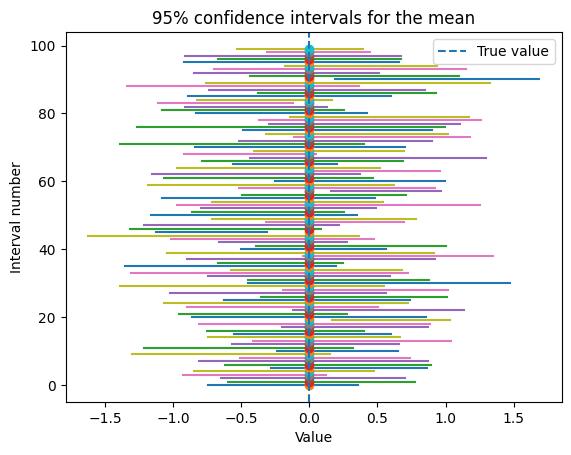

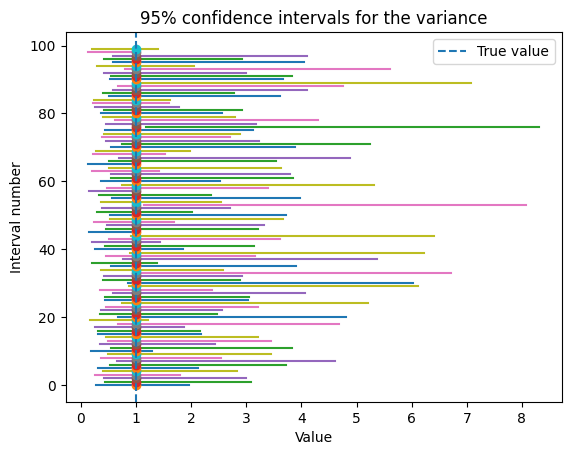

In [22]:
plot_intervals(mean_intervals, 0, "95% confidence intervals for the mean")
plot_intervals(variance_intervals, 1, "95% confidence intervals for the variance")

## Part 4

In [23]:
def pareto_composition(n, mu=1):
    # Step 1: Generate Y ~ Exp(mu)
    U1 = np.random.uniform(0, 1, n)
    Y = -np.log(U1) / mu

    # Step 2: Given Y = y, generate X ~ Exp(y)
    U2 = np.random.uniform(0, 1, n)
    X = -np.log(U2) / Y

    return X

### Generate observations

In [24]:
n = 10000
mu = 1

pareto_comp_data = pareto_composition(n, mu)

In [25]:
def pareto_direct_nonnegative(n, k=1, beta=1):
    U = np.random.uniform(0, 1, n)
    return beta * (U ** (-1 / k) - 1)

In [26]:
pareto_direct_data = pareto_direct_nonnegative(n, k=1, beta=mu)

### Generate plots

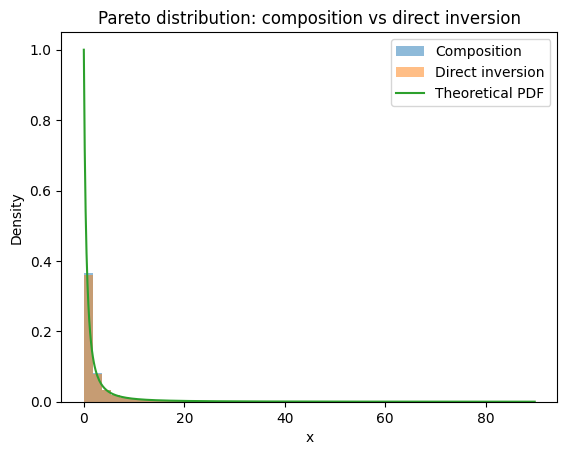

In [27]:
upper = min(
    np.percentile(pareto_comp_data, 99),
    np.percentile(pareto_direct_data, 99)
)

plt.hist(pareto_comp_data, bins=50, range=(0, upper), density=True, alpha=0.5, label="Composition")
plt.hist(pareto_direct_data, bins=50, range=(0, upper), density=True, alpha=0.5, label="Direct inversion")

x = np.linspace(0, upper, 500)
theoretical_pdf = mu / (mu + x)**2

plt.plot(x, theoretical_pdf, label="Theoretical PDF")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Pareto distribution: composition vs direct inversion")
plt.legend()
plt.show()

### Fit-tests

In [28]:
ks_comp = stats.kstest(pareto_comp_data, "lomax", args=(1, 0, mu))
ks_direct = stats.kstest(pareto_direct_data, "lomax", args=(1, 0, mu))

print("Composition method:")
print("KS statistic:", ks_comp.statistic)
print("p-value:", ks_comp.pvalue)

print()

print("Direct inversion method:")
print("KS statistic:", ks_direct.statistic)
print("p-value:", ks_direct.pvalue)

Composition method:
KS statistic: 0.008606537404522663
p-value: 0.4468046856252279

Direct inversion method:
KS statistic: 0.00657330147933774
p-value: 0.7779619446980193
